In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix

from sklearn.preprocessing import LabelEncoder

import joblib

# Define the path to the Excel file
file_path = "Prediction_Data.xlsx"

# Define the sheet name to read data from
sheet_name = 'vw_ChurnData'

 

# Read the data from the specified sheet into a pandas DataFrame
data = pd.read_excel(file_path, sheet_name=sheet_name)

 

# Display the first few rows of the fetched data
print(data.head())



  Customer_ID  Gender  Age  Married            State  Number_of_Referrals  \
0   72044-HAR  Female   32     True          Haryana                    0   
1   79738-UTT  Female   33     True    Uttar Pradesh                    1   
2   12622-MAD  Female   34    False   Madhya Pradesh                   15   
3   68740-CHH  Female   38    False     Chhattisgarh                    8   
4   62473-JAM    Male   60     True  Jammu & Kashmir                    1   

   Tenure_in_Months Value_Deal  Phone_Service  Multiple_Lines  ...  \
0                 5     Deal 3           True           False  ...   
1                 6       None           True           False  ...   
2                36       None           True           False  ...   
3                16       None           True           False  ...   
4                14     Deal 4           True           False  ...   

    Payment_Method Monthly_Charge  Total_Charges  Total_Refunds  \
0      Credit Card          18.55         689.00 

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Drop irrelevant identifiers and data leakage features
data = data.drop(
    ['Customer_ID', 'Churn_Category', 'Churn_Reason'],
    axis=1,
    errors='ignore',
)

# 2. Define categorical columns for encoding
columns_to_encode = [
    'Gender',
    'Married',
    'State',
    'Value_Deal',
    'Multiple_Lines',
    'Internet_Service',
    'Internet_Type',
    'Online_Security',
    'Online_Backup',
    'Premium_Support',
    'Phone_Service',
    'Streaming_TV',
    'Unlimited_Data',
    'Streaming_Movies',
    'Device_Protection_Plan',
    'Streaming_Music',
    'Contract',
    'Paperless_Billing',
    'Payment_Method',
]

# 3. Label encode categorical features iteratively
label_encoders = {}
for column in columns_to_encode:
  if column in data.columns:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(
        data[column].astype(str)
    )

# 4. Map target variable to binary values
if 'Customer_Status' in data.columns:
  data['Customer_Status'] = data['Customer_Status'].map(
      {'Stayed': 0, 'Churned': 1}
  )

# 5. Split dataset into training and testing sets
X = data.drop('Customer_Status', axis=1, errors='ignore')
y = data['Customer_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('✅ Execution successful! Dataset shapes:')
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

✅ Execution successful! Dataset shapes:
X_train: (4805, 28)
X_test: (1202, 28)


In [3]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

 

# Train the model

rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Confusion Matrix:
[[791  52]
 [124 235]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       843
           1       0.82      0.65      0.73       359

    accuracy                           0.85      1202
   macro avg       0.84      0.80      0.81      1202
weighted avg       0.85      0.85      0.85      1202



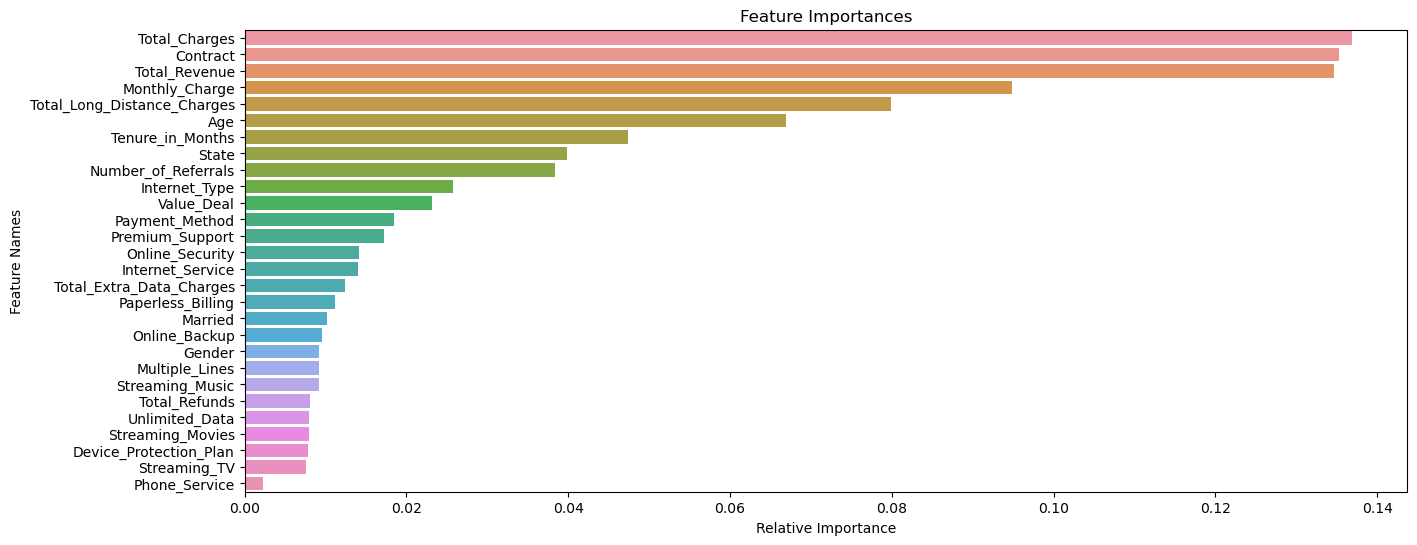

In [4]:


# Make predictions

y_pred = rf_model.predict(X_test)

 

# Evaluate the model

print("Confusion Matrix:")

print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")

print(classification_report(y_test, y_pred))

 

# Feature Selection using Feature Importance

importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1]

 

# Plot the feature importances

plt.figure(figsize=(15, 6))

sns.barplot(x=importances[indices], y=X.columns[indices])

plt.title('Feature Importances')

plt.xlabel('Relative Importance')

plt.ylabel('Feature Names')
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
import numpy as np
import pandas as pd

# Feature importance
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Keep features with importance >= 0.01
selected_features = feature_importance_df[
    feature_importance_df['Importance'] >= 0.01
]['Feature'].tolist()

print("Selected features:")
print(selected_features)

print(f"\nOriginal number of features: {X_train.shape[1]}")
print(f"Selected number of features: {len(selected_features)}")

# Apply feature selection
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

Selected features:
['Total_Charges', 'Contract', 'Total_Revenue', 'Monthly_Charge', 'Total_Long_Distance_Charges', 'Age', 'Tenure_in_Months', 'State', 'Number_of_Referrals', 'Internet_Type', 'Value_Deal', 'Payment_Method', 'Premium_Support', 'Online_Security', 'Internet_Service', 'Total_Extra_Data_Charges', 'Paperless_Billing', 'Married']

Original number of features: 28
Selected number of features: 18


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

rf_selected = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    rf_selected,
    X_train_selected,
    y_train,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

print("5-Fold Cross Validation Results:")

print(f"Mean Accuracy:  {cv_results['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Mean Recall:    {cv_results['test_recall'].mean():.4f}")
print(f"Mean F1 Score:  {cv_results['test_f1'].mean():.4f}")
print(f"Mean ROC-AUC:   {cv_results['test_roc_auc'].mean():.4f}")

5-Fold Cross Validation Results:
Mean Accuracy:  0.8475
Mean Precision: 0.8025
Mean Recall:    0.6206
Mean F1 Score:  0.6994
Mean ROC-AUC:   0.8950


In [7]:
# Train final model using selected features
rf_selected.fit(
    X_train_selected,
    y_train
)

# Predict probabilities
y_prob = rf_selected.predict_proba(
    X_test_selected
)[:, 1]

In [8]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"Test ROC-AUC: {roc_auc:.4f}")

Test ROC-AUC: 0.9037


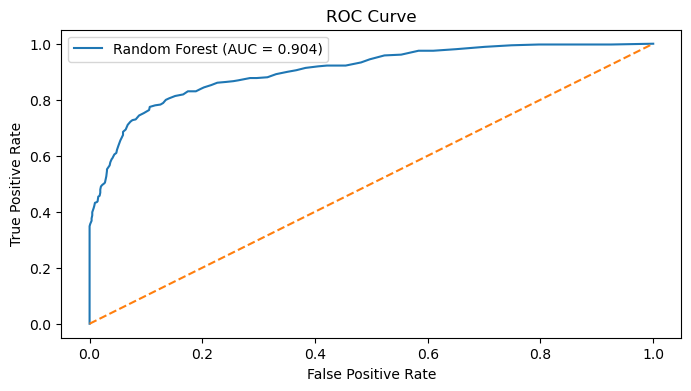

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

roc_auc = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 4))

plt.plot(
    fpr,
    tpr,
    label=f'Random Forest (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.savefig(
    'roc_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [10]:
file_path = "Prediction_Data.xlsx"
sheet_name = "vw_JoinData"

new_data = pd.read_excel(file_path, sheet_name=sheet_name)
original_data = new_data.copy()

new_data = new_data.drop(
    ['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'],
    axis=1,
    errors='ignore'
)

for column in new_data.select_dtypes(include=['object']).columns:
    if column in label_encoders:
        new_data[column] = label_encoders[column].transform(
            new_data[column].astype(str)
        )

new_data = new_data[selected_features]

new_predictions = rf_selected.predict(new_data)
new_probabilities = rf_selected.predict_proba(new_data)[:, 1]

original_data['Churn_Probability'] = new_probabilities
original_data['Customer_Status_Predicted'] = new_predictions

original_data['Customer_Status_Predicted'] = (
    original_data['Customer_Status_Predicted']
    .map({0: 'Stayed', 1: 'Churned'})
)

original_data = original_data[
    original_data['Customer_Status_Predicted'] == 'Churned'
].sort_values(
    'Churn_Probability',
    ascending=False
)

original_data.to_csv("Predictions.csv", index=False)

print("Prediction completed!")
print(f"Predicted churn customers: {len(original_data)}")

Prediction completed!
Predicted churn customers: 380
